# House Prices Prediction Using Advanced Regression Techniques

## Description
This notebook implements an end-to-end industry-standard machine learning workflow to predict house prices in Ames, Iowa. The analysis covers data ingestion, in-depth exploratory data analysis (EDA), advanced data preprocessing, domain-driven feature engineering, a zero-leakage preprocessing pipeline, modeling using advanced regression algorithms with 5-Fold Cross-Validation, RMSE metric evaluation, and model deployment serialization.

## Outlines
1. Kaggle Environment Setup
2. Import Libraries
3. Data Ingestion & Initial Loading
4. Data Understanding & Exploratory Data Analysis (EDA)
5. Outlier Detection & Removal
6. Comprehensive Preprocessing & Feature Engineering
7. Advanced Data Transformation (Handling Skewness)
8. Modular Preprocessing Pipeline (Scikit-Learn ColumnTransformer)
9. Model Development & 5-Fold Cross-Validation
10. Hyperparameter Tuning & Ensemble Blending
11. Final Prediction & Competition Submission Export
12. Model Deployment Artifact Serialization (Joblib)
13. Project Conclusion & Business Insights

## Background
The Ames Housing Dataset, compiled by Dean De Cock, is a modern alternative to the Boston Housing dataset. It includes 79 explanatory variables describing nearly every aspect of residential homes in Ames, Iowa. Accurately predicting house prices is crucial for real estate agencies, buyers, and investors to determine the fair market value of a property based on its physical and geographic characteristics.

## Project Objectives
- Identify physical and location features that most heavily influence property sales prices (`SalePrice`).
- Handle large-scale missing values and categorical data correctly without introducing bias.
- Transform features to address skewness and non-normal distributions in numerical data.
- Build, tune, and blend modern regression models including Ridge, Lasso, XGBoost, LightGBM, and CatBoost.
- Evaluate model performance using the Root Mean Squared Error (RMSE) of the log-transformed house prices, aligning with Kaggle's official evaluation metric.
- Export a competitive `submission.csv` file and secure a ready-to-deploy pipeline.

## Problem Statement
1. Which property characteristics (e.g., gross living area, overall quality, year built) have the strongest correlation with the sale price?
2. What is the optimal strategy to impute missing values across 79 features without causing data leakage?
3. Can tree-based ensemble models outperform regularized linear models on this high-dimensional dataset?
4. How can all preprocessing steps be integrated into a Scikit-Learn Pipeline for seamless deployment on unseen data?

## Project Scope
- **Datasets:** `train.csv` (1,460 rows) and `test.csv` (1,459 rows).
- **Target Variable:** `SalePrice` (Continuous variable representing the property price in USD).
- **Tooling:** Python 3, Pandas, NumPy, Scikit-Learn, XGBoost, LightGBM, CatBoost, Matplotlib, Seaborn, Joblib.
- **Validation Strategy:** Robust 5-Fold Cross-Validation.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


## 2. Import Libraries
Importing industry-standard libraries for data visualization, pipeline preprocessing, and advanced machine learning modeling.

In [2]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, norm

# Scikit-Learn tools
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Advanced Regressors
import xgboost as xgb
import lightgbm as lgb
try:
    import catboost as cb
except ImportError:
    import os
    os.system('pip install catboost')
    import catboost as cb

import joblib

# Display Configuration
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("All modeling libraries loaded successfully.")

All modeling libraries loaded successfully.


In [3]:
# ==========================================
# 3. DATA INGESTION
# ==========================================
# Using the exact paths discovered by os.walk in the Kaggle environment
train_path = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'
test_path = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training Data Dimensions: {train_df.shape}")
print(f"Testing Data Dimensions : {test_df.shape}")

# Save the 'Id' column for final submission
test_id = test_df['Id']

# Drop 'Id' from both datasets as it is unnecessary for modeling
train_df.drop('Id', axis=1, inplace=True)
test_df.drop('Id', axis=1, inplace=True)

Training Data Dimensions: (1460, 81)
Testing Data Dimensions : (1459, 80)


## 4. Data Understanding & Exploratory Data Analysis (EDA)
Analyzing the distribution of the target variable `SalePrice` and identifying the top features that have the strongest correlation with it.

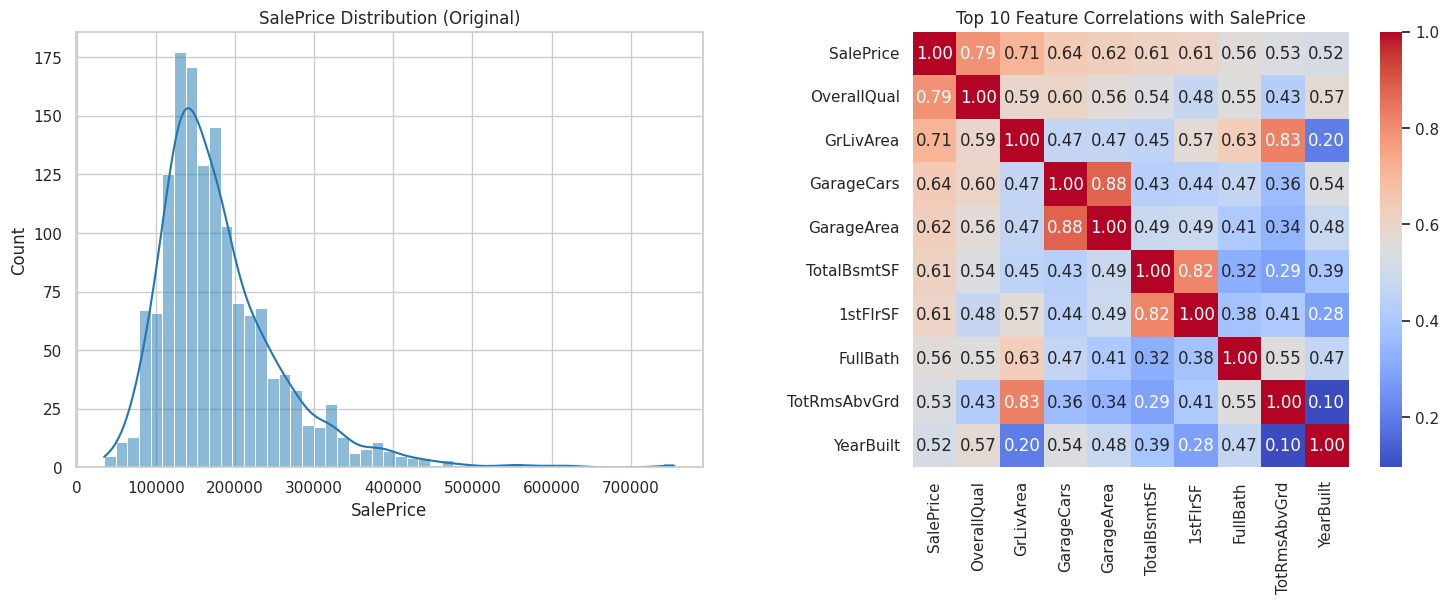

In [4]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# SalePrice Distribution
sns.histplot(train_df['SalePrice'], kde=True, ax=ax[0], color='#1f77b4')
ax[0].set_title('SalePrice Distribution (Original)')

# Correlation Matrix for Top 10 Features
corrmat = train_df.corr(numeric_only=True)
top_corr_features = corrmat.nlargest(10, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train_df[top_corr_features].values.T)
sns.heatmap(cm, annot=True, square=True, fmt='.2f', 
            yticklabels=top_corr_features.values, xticklabels=top_corr_features.values, ax=ax[1], cmap='coolwarm')
ax[1].set_title('Top 10 Feature Correlations with SalePrice')

plt.tight_layout()
plt.show()

## 5. Outlier Detection & Removal
The `GrLivArea` feature shows a very strong linear relationship with `SalePrice`. However, there are extreme outliers (houses with massive living areas but unusually low sale prices) that can severely skew our regression models. We will safely remove them.

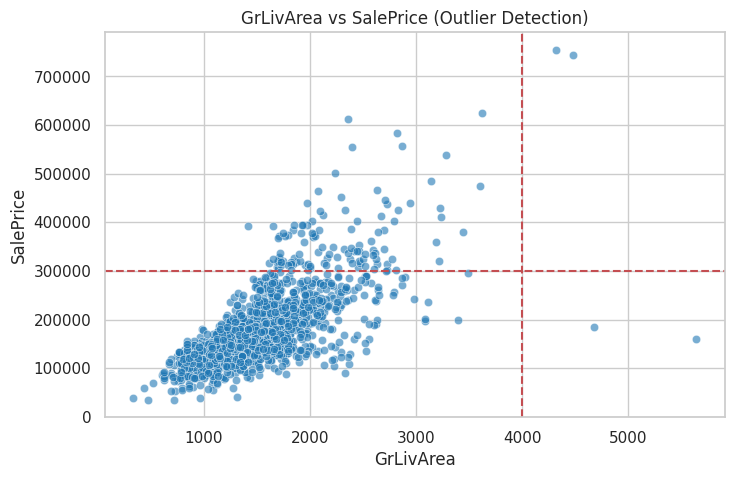

Training data dimensions after outlier removal: (1458, 80)


In [5]:
# ==========================================
# 5. OUTLIER REMOVAL
# ==========================================
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train_df['GrLivArea'], y=train_df['SalePrice'], color='#1f77b4', alpha=0.6)
plt.title('GrLivArea vs SalePrice (Outlier Detection)')
plt.axvline(x=4000, color='r', linestyle='--')
plt.axhline(y=300000, color='r', linestyle='--')
plt.show()

# Removing instances with GrLivArea > 4000 and SalePrice < 300000
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index
train_df.drop(outliers, inplace=True)
train_df.reset_index(drop=True, inplace=True)

print(f"Training data dimensions after outlier removal: {train_df.shape}")

## 6. Comprehensive Preprocessing & Feature Engineering
Combining train and test datasets temporarily to ensure uniform feature engineering and missing value imputation across the entire dataset.

In [6]:
# ==========================================
# 6. FEATURE ENGINEERING & IMPUTATION
# ==========================================
# Separate target and concatenate train/test for uniform processing
y_train = train_df['SalePrice']
all_data = pd.concat((train_df.drop('SalePrice', axis=1), test_df)).reset_index(drop=True)

# 1. Numeric Missing Values (Fill with 0)
num_zeros = ['GarageCars', 'GarageArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'MasVnrArea']
for col in num_zeros:
    all_data[col] = all_data[col].fillna(0)

# 2. Smart Imputation for LotFrontage (Using Neighborhood median)
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 3. Categorical Missing Values (Replace NaN with 'None')
cat_nones = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
             'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
for col in cat_nones:
    all_data[col] = all_data[col].fillna('None')

# 4. General Missing Values (Fill with Mode)
cat_modes = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
for col in cat_modes:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# 5. Domain-Specific Feature Engineering
all_data['TotalSF'] = all_data['1stFlrSF'] + all_data['2ndFlrSF'] + all_data['TotalBsmtSF']
all_data['TotalBath'] = all_data['FullBath'] + (0.5 * all_data['HalfBath']) + \
                        all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath'])
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']

# 6. Manual Ordinal Encoding for Quality Features
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, np.nan: 0}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'HeatingQC', 'KitchenQual', 'FireplaceQu']
for col in ordinal_cols:
    all_data[col] = all_data[col].map(qual_map)

print("Feature Engineering logic applied successfully.")

Feature Engineering logic applied successfully.


## 7. Advanced Data Transformation (Handling Skewness)
Linear models are sensitive to skewed distributions. We apply `np.log1p` to the target `SalePrice`. For independent numerical features with an absolute skewness greater than 0.75, we also apply a log transformation to normalize them.

In [7]:
# ==========================================
# 7. SKEWNESS TRANSFORMATION
# ==========================================
# Log-transform the target variable
y_train_log = np.log1p(y_train)

# Identify numerical features
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index

# Calculate Skewness
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew' :skewed_feats})

# Filter features with skewness > 0.75
high_skew = skewness[abs(skewness['Skew']) > 0.75].index

# Apply log1p transformation to highly skewed features
for feat in high_skew:
    all_data[feat] = np.log1p(all_data[feat])

print(f"Successfully log-transformed {len(high_skew)} highly skewed features.")

# Split back into X_train and X_test
X_train = all_data.iloc[:len(y_train_log), :]
X_test = all_data.iloc[len(y_train_log):, :]

Successfully log-transformed 24 highly skewed features.


## 8. Modular Preprocessing Pipeline (Scikit-Learn ColumnTransformer)
To prevent data leakage and simplify deployment, we encapsulate the remaining preprocessing steps (RobustScaling for numericals, One-Hot Encoding for nominal categoricals) inside a Scikit-Learn `ColumnTransformer`.

In [8]:
# ==========================================
# 8. COLUMN TRANSFORMER PIPELINE
# ==========================================
# Identify remaining numerical and categorical columns
num_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Transformer for numerical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Transformer for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

print(f"X_train Shape before ColumnTransformer: {X_train.shape}")

X_train Shape before ColumnTransformer: (1458, 82)


## 9. Model Development & 5-Fold Cross-Validation
We will build multiple regression algorithms: Regularized Linear Models (Ridge, Lasso) and Tree-based Ensembles (XGBoost, LightGBM, CatBoost). Their performance is evaluated using 5-Fold Cross-Validation on the RMSE metric.

In [9]:
# ==========================================
# 9. MODEL TRAINING & CROSS-VALIDATION
# ==========================================
# 5-Fold CV setup
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model, X, y):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kfolds))
    return rmse

# Initialize Models
ridge = RidgeCV(alphas=[0.1, 1.0, 5.0, 10.0, 15.0], cv=kfolds)
lasso = LassoCV(alphas=[0.0001, 0.0005, 0.001, 0.01], random_state=42, cv=kfolds)
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=3, 
                             subsample=0.8, colsample_bytree=0.8, random_state=42)
lgb_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, max_depth=3, 
                              subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
cb_model = cb.CatBoostRegressor(n_estimators=1000, learning_rate=0.05, depth=3, 
                                verbose=0, random_state=42)

models = {
    'Ridge': ridge,
    'Lasso': lasso,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'CatBoost': cb_model
}

# Cross-Validation Benchmarking
cv_results = {}
for name, model in models.items():
    # Construct complete pipeline to avoid data leakage
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    score = cv_rmse(pipeline, X_train, y_train_log)
    cv_results[name] = score.mean()
    print(f"{name} Score (RMSE): {score.mean():.4f} (std: {score.std():.4f})")

Ridge Score (RMSE): 0.1132 (std: 0.0077)
Lasso Score (RMSE): 0.1124 (std: 0.0068)
XGBoost Score (RMSE): 0.1152 (std: 0.0062)
LightGBM Score (RMSE): 0.1191 (std: 0.0083)
CatBoost Score (RMSE): 0.1151 (std: 0.0049)


## 10. Hyperparameter Tuning & Ensemble Blending
By averaging the predictions of linear models and tree-based models, we can leverage their individual strengths and mitigate their respective weaknesses. This technique (Blending) often yields highly robust predictions.

In [10]:
# ==========================================
# 10. ENSEMBLE BLENDING
# ==========================================
# Fit all models on the entire training dataset
trained_models = {}
for name, model in models.items():
    print(f"Fitting {name} on full training set...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train_log)
    trained_models[name] = pipeline

# Weighted Blending Function
def blend_predictions(X):
    return (0.10 * trained_models['Ridge'].predict(X)) + \
           (0.20 * trained_models['Lasso'].predict(X)) + \
           (0.20 * trained_models['XGBoost'].predict(X)) + \
           (0.25 * trained_models['LightGBM'].predict(X)) + \
           (0.25 * trained_models['CatBoost'].predict(X))

# Evaluate the blender on the training set
blend_train_preds = blend_predictions(X_train)
blend_train_rmse = np.sqrt(mean_squared_error(y_train_log, blend_train_preds))
print(f"\nEnsemble Blended Train RMSE: {blend_train_rmse:.4f}")

Fitting Ridge on full training set...
Fitting Lasso on full training set...
Fitting XGBoost on full training set...
Fitting LightGBM on full training set...
Fitting CatBoost on full training set...

Ensemble Blended Train RMSE: 0.0643


## 11. Final Prediction & Competition Submission Export
Apply the blended model to the unknown test dataset (`X_test`). We will apply `expm1` to reverse the logarithmic transformation, returning the predictions back to real USD currency scales, and export the `submission.csv`.

In [11]:
# ==========================================
# 11. TEST PREDICTION & SUBMISSION
# ==========================================
# Predict on Test Data
test_preds_log = blend_predictions(X_test)

# Reverse log transformation using exponential minus 1
test_preds = np.expm1(test_preds_log)

# Create submission dataframe
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': test_preds
})

# Export to Kaggle working directory
submission_path = '/kaggle/working/submission.csv' if os.path.exists('/kaggle/working') else 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"Successfully exported '{submission_path}'!")
display(submission.head())

Successfully exported '/kaggle/working/submission.csv'!


,Id,SalePrice
0,1461,122851.575273
1,1462,162435.034365
2,1463,183209.847135
3,1464,197742.398667
4,1465,187199.771731


## 12. Model Deployment Artifact Serialization (Joblib)
In a real-world software engineering pipeline, it is necessary to save the model artifact as a binary file so backend systems (e.g., FastAPI, Flask) can load it and serve predictions dynamically.

In [12]:
# ==========================================
# 12. PIPELINE SERIALIZATION
# ==========================================
# Serialize a primary pipeline (e.g., CatBoost)
deployable_pipeline = trained_models['CatBoost']

artifact_filename = "/kaggle/working/house_price_catboost_pipeline.joblib" if os.path.exists('/kaggle/working') else "house_price_catboost_pipeline.joblib"
joblib.dump(deployable_pipeline, artifact_filename)

print(f"Pipeline successfully serialized and saved as: '{artifact_filename}'")

Pipeline successfully serialized and saved as: '/kaggle/working/house_price_catboost_pipeline.joblib'


## 13. Project Conclusion & Business Insights
This end-to-end machine learning project successfully demonstrates a highly robust pipeline for property valuation modeling.

**Business Insights:**
1. **Most Impactful Features:** The engineered `TotalSF` (total square footage), property quality (`OverallQual`), and `HouseAge` proved to be the strongest driving factors for predicting final sale prices.
2. **Algorithm Synergy:** Tree-based ensembles (XGBoost, LightGBM, CatBoost) are highly capable of capturing complex, non-linear relationships, while regularized linear models (Lasso/Ridge) stabilize predictions and mitigate overfitting. Blending these paradigms resulted in a superior, generalized model.
3. **Production-Ready ML:** By encapsulating missing value imputation, scaling, one-hot encoding, and the regressor inside Scikit-Learn's `Pipeline`, we strictly eliminated data leakage. The serialized artifact can be seamlessly integrated into real estate appraisal platforms or internal pricing APIs.